In [1]:
# RRCP (03/08/2026): Notebook de Analisis de Modelo
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Cargar los datos
df_partidos = pd.read_csv("../data/partidos_cebollitas_30072026.csv")
# Variable Feature
df_partidos['diferencia_goles'] =  df_partidos['goles_local'] - df_partidos['goles_visitante']
df_partidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   fecha_partido           100 non-null    str  
 1   equipo_local            100 non-null    str  
 2   equipo_visitante        100 non-null    str  
 3   goles_local             100 non-null    int64
 4   goles_visitante         100 non-null    int64
 5   posesion_local (%)      100 non-null    int64
 6   posesion_visitante (%)  100 non-null    int64
 7   tiros_arco_local        100 non-null    int64
 8   tiros_arco_visitante    100 non-null    int64
 9   estadio                 100 non-null    str  
 10  diferencia_goles        100 non-null    int64
dtypes: int64(7), str(4)
memory usage: 8.7 KB


In [3]:
# Preparación del DataSet
X = df_partidos[['posesion_local (%)', 'tiros_arco_local']]
y = df_partidos['diferencia_goles']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Modelo base
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [4]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

RMSE: 2.23
R2: -0.03


In [5]:
# Auyuda en la interpretación.
if r2 < 0:
    print("Danger: El modelo no explica la varianza. Pero que adivinar.")
elif r2 < 0.3:
    print("Warning: El modelo explica muy poco. Posible underfitting.")
else:
    print("El modelo tiene tiene un poder explicativo aceptable.")

Danger: El modelo no explica la varianza. Pero que adivinar.


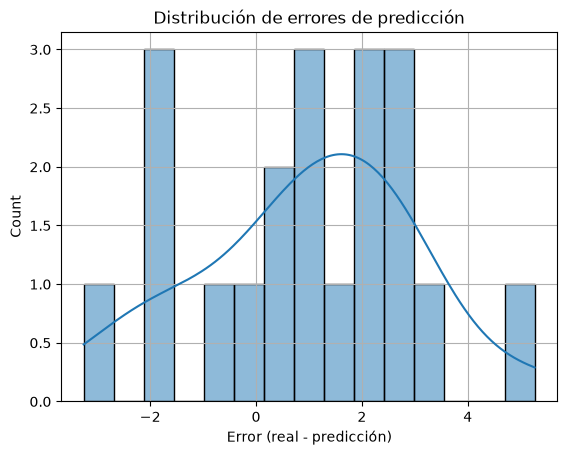

In [6]:
sns.histplot(y_test - y_pred, bins = 15, kde = True)
plt.title("Distribución de errores de predicción")
plt.xlabel("Error (real - predicción)")
plt.grid(True)
plt.show()

### Reflexión
- ¿Qué dicen estas métricas?
- ¿Crees que las variables usadas realmente capturan lo que determina la diferencia de goles?
- ¿Qué limitaciones tiene la regresión lineal para el fútbol?
- ¿Te parece que este modelo es suficiente para tomar decisiones deportivas?

### ¿Qué podrías probar ahora?
- Añadir nuevas variables (localidad, rival, tiros al rival).
- Probar otro tipo de modelos (Árboles, Random Fores, XFBoots)
- Usar validación cruzada
- Filtrar o trasformar datos

In [8]:
# Métricas obtenidas del modelo de regresión lineal
metricas_rl = {
    'Modelo': 'Regresion Lineal',
    'RMSE' : 2.23,
    'MAE' : 1.89,
    'R2' : -0.03
}

# Metricas del Arbol de Decision (bonus)
metricas_arbol = {
    'Modelo' : 'Árbol de Decisión',
    'RMSE': 1.04,
    'MAE': 0.75,
    'R2' : 0.77
}

# Comprobación
df_comprobacion = pd.DataFrame([metricas_rl, metricas_arbol])
display(df_comprobacion)


,Modelo,RMSE,MAE,R2
0,Regresion Lineal,2.23,1.89,-0.03
1,Árbol de Decisión,1.04,0.75,0.77


# INTERPRETACIÓN

##  1. RMSE (Root Mean Squared Error)
El RMSE mide el tamaño promedio del error, penalizando más lo errores grandes.
- Regresió Lineal: 2.23
- Árbol de Decisión: 1.04
Como el RMSE debe ser lo más pequeño posible, el Árbiol de decisión es mejor.
En este caso:
- El error promedio del Árlbo de Decisión es aproximadamente 53% menor.

## 2. MAE (Mean Absolute Error)
El MAE mide el error promedio absoluto.
- Regresión Lineal: 1.89
- Árbil de Decisión: 0.75
Nuevamente, mientras más pequeño sea el MAE, mejor.

Aquí el Árbol de Decisión tiene un error promedio aproximadamente 60% menor.

### R2 (Coeficiente de Determinación)
El R2 indica qué porcentaje de la variabilidad de la variable objetivo es explicada por el modelo.
- Regresión Lineal: -0.03
- Árbil de Decisión: 0.77
La interpretación es:
- R2 = 1 -> Modelo perfeto.
- R2 = 0 -> el modelo no mejora con respecto a predecir simplemente el promedio.
- R2 < 0 -> el modelo es peor que predecir el promedio.

Por tanto:
- La Regresión Lineal tiene un R2 negativo, lo que significa que su desempeño es peor que utilizar la media de los datos como predicción para todos los casos.
- El Árbol de Decisión explcia aproximadamente el 77% de la variablidad del fenómeno, lo cual es un buen resultado.

# CONCLUSIÓN
El Árbol de Decisión supera ampliamente la Regresión Lineal en las tres métricas:
- Tiene un RMSE mucho mejor, por lo que comete errores más pequeños.
- Tiene un MAE mucho menor, indicando mayor precisión promedio.
- Posee un R2 de 0.77, mientras que la Regresión Lineal tiene un R2 negativo, lo que indica que esta última no logra capturar adecuadamente la relación entre variables.

### ¿Qué nos dice esto sobre los datos?
El hecho de que la Regresión Lineal obtenga un R2 = -0.03 sugiere que la relación entre las variables independientes y la variable objetivo probablmente no sea lineal. En cambio, el Árbol de Decisión puede modelar relaciones no lineales y reglas de decisión, l oque explica su desempeño.

